In [1]:
# import library
import pandas as pd  #olah data (DataFrame)
import numpy as np  #hitungan numerik
import matplotlib.pyplot as plt  #visualisasi grafik
from sklearn.linear_model import LinearRegression  #model regresi linear
from sklearn.model_selection import train_test_split  #membagi data training & test
from sklearn import metrics  #evaluasi hasil model

In [2]:
# dataset
data = {
    'waktu_olahraga': [10, 20, 30, 40, 50, 60],
    'kalori': [50, 100, 150, 210, 260, 320]
}

df = pd.DataFrame(data)
print(df)

   waktu_olahraga  kalori
0              10      50
1              20     100
2              30     150
3              40     210
4              50     260
5              60     320


In [3]:
X = df[['waktu_olahraga']] #variabel independen (input)
y = df['kalori'] #variabel dependen (output)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Data dibagi menjadi:

- 80% training

- 20% testing

random_state=42 agar hasil konsisten

In [5]:
model = LinearRegression() #membuat model regresi linear
model.fit(X_train, y_train) #melatih model menggunakan data training

LinearRegression()

In [6]:
# melihat atau menghitung koefisien
print("Intercept (a):", model.intercept_) #nilai kalori saat waktu olahraga = 0
print("Koefisien (b):", model.coef_[0]) #perubahan kalori setiap penambahan 1 menit waktu olahraga

Intercept (a): -17.00000000000003
Koefisien (b): 5.6000000000000005


In [7]:
y_pred = model.predict(X_test) #prediksi data testing

print("Data Testing:")
print(X_test)
print("Kalori Asli:", y_test.values)
print("Kalori Prediksi:", y_pred)

Data Testing:
   waktu_olahraga
0              10
1              20
Kalori Asli: [ 50 100]
Kalori Prediksi: [39. 95.]


In [8]:
# evaluasi model regresi
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 8.000000000000018
MSE: 73.00000000000031
RMSE: 8.54400374531755


In [9]:
prediksi = model.predict([[45]])
print("Prediksi kalori untuk 45 menit olahraga:", prediksi[0])

Prediksi kalori untuk 45 menit olahraga: 235.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


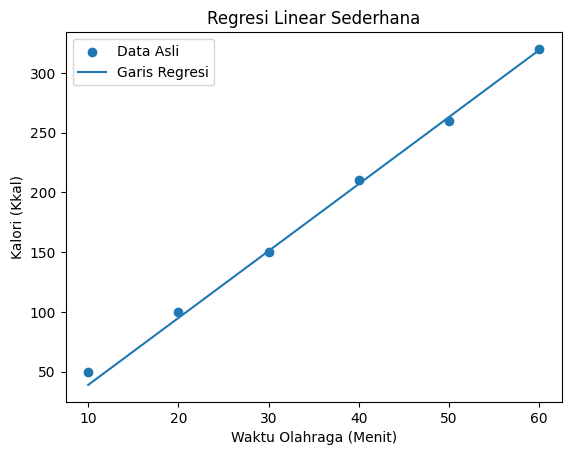

In [10]:
plt.scatter(X, y, label="Data Asli") #menampilkan data asli dalam bentuk titik
plt.plot(X, model.predict(X), label="Garis Regresi") #menampilkan garis hasil model regresi
plt.xlabel("Waktu Olahraga (Menit)")
plt.ylabel("Kalori (Kkal)")
plt.title("Regresi Linear Sederhana")
plt.legend()
plt.show()

Hasil analisis menunjukkan bahwa waktu olahraga memiliki pengaruh positif terhadap jumlah kalori yang terbakar, di mana semakin lama waktu olahraga maka kalori yang dihasilkan juga semakin meningkat. Model yang digunakan juga mampu memprediksi dengan cukup baik, terlihat dari hasil prediksi yang mendekati nilai aktual serta nilai error yang relatif kecil.